### Load Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Load Data

In [2]:
# Path to project directory
path_proj = "/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification"

In [3]:
import medmnist
from medmnist import BloodMNIST
print(medmnist.__version__)

3.0.2


In [4]:
# Download BloodMNIST metadata
from medmnist import INFO
data_flag = "bloodmnist"
info = INFO[data_flag]

In [5]:
# Download BloodMNIST data
train_data = BloodMNIST(split="train", root=f"{path_proj}/data", download=True)
val_data   = BloodMNIST(split="val", root=f"{path_proj}/data", download=True)
test_data  = BloodMNIST(split="test", root=f"{path_proj}/data", download=True)

In [6]:
# Extract observations and labels from BloodMNIST object
X_train = train_data.imgs
y_train = train_data.labels.ravel()

X_val = val_data.imgs
y_val = val_data.labels.ravel()

X_test = test_data.imgs
y_test = test_data.labels.ravel()

In [7]:
print(type(X_train))
print(X_train.shape) # num_samples x height x width x channels
print(y_train.shape) # num_samples x 1

<class 'numpy.ndarray'>
(11959, 28, 28, 3)
(11959,)


### Data Preprocessing

In [8]:
# Flatten
X_train_flat = X_train.reshape(X_train.shape[0], -1)
print(X_train_flat.shape)

X_val_flat = X_val.reshape(X_val.shape[0], -1)
print(X_val_flat.shape)

X_test_flat = X_test.reshape(X_test.shape[0], -1)
print(X_test_flat.shape)

(11959, 2352)
(1712, 2352)
(3421, 2352)


In [9]:
# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_flat_scaled = scaler.fit_transform(X_train_flat)
X_val_flat_scaled = scaler.transform(X_val_flat)
X_test_flat_scaled = scaler.transform(X_test_flat)

### Softmax (Multinomial Logistic) Regression

Softmax score for class k: $$s_{k}(x)=(\theta^{(k)})^{T}x$$

Estimated probability for class k: $$\widehat{p}_{k} =\sigma(s(x))_{k}=\frac{exp(s_{k}(x))}{\sum_{j=1}^{K}x_{j}}$$

Softmax cost function (cross-entropy): $$J(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K}y_{k}^{(i)}log(\widehat{p}_{k}^{(i)})$$

In [10]:
# Construct a LogisticRegression model
from sklearn.linear_model import LogisticRegression
softmax_regressor = LogisticRegression(
    C=1, 
    l1_ratio=0,
    solver='lbfgs', 
    max_iter=1000, 
    tol=1e-4,
    random_state=42, 
    verbose=1
)

In [11]:
# Train the model
import time
start = time.time()
softmax_regressor.fit(X_train_flat_scaled, y_train)
elapsed = time.time() - start
print(f"Training time: {elapsed:.2f} seconds")

Training time: 20.40 seconds


In [12]:
# Predict for validation data
y_pred_softmax_regressor = softmax_regressor.predict(X_val_flat_scaled)

In [13]:
# Accuracy on validation predictions
from sklearn.metrics import accuracy_score
accuracy_score(y_val, y_pred_softmax_regressor)

0.8078271028037384

In [14]:
# Accuracy with cross-validation on training data
from sklearn.model_selection import cross_val_score

cv_scores_softmax_regression = cross_val_score(
    softmax_regressor, X_train_flat_scaled, y_train, cv=3, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores_softmax_regression}")

Cross-validation scores: [0.77827941 0.77295534 0.77170095]


In [15]:
# Confusion matrix
from sklearn.model_selection import cross_val_predict

cv_predictions_softmax_regression = cross_val_predict(
    softmax_regressor, X_train_flat_scaled, y_train, cv=3)
print(f"Cross-validation predictions: {cv_predictions_softmax_regression}")

Cross-validation predictions: [7 3 6 ... 1 6 3]


In [16]:
from sklearn.metrics import confusion_matrix

cm_softmax_regression = confusion_matrix(y_train, cv_predictions_softmax_regression)
cm_softmax_regression

array([[ 502,   26,   16,  223,   36,   29,   20,    0],
       [  31, 1984,    3,   18,    9,   19,  114,    3],
       [  12,    8,  884,   37,   70,   10,   47,   17],
       [ 188,   33,   55, 1202,   80,  328,  140,    0],
       [  31,    2,   69,   79,  621,   23,   23,    1],
       [  39,   10,   12,  315,   16,  572,   29,    0],
       [  34,  114,   82,  147,   36,   34, 1874,    9],
       [   0,    1,    4,    1,    4,    0,   12, 1621]])

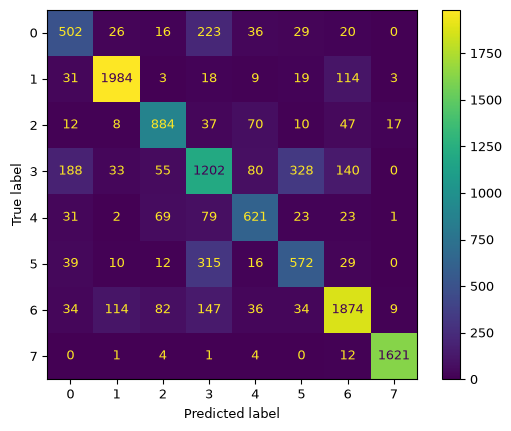

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, cv_predictions_softmax_regression)
plt.show()

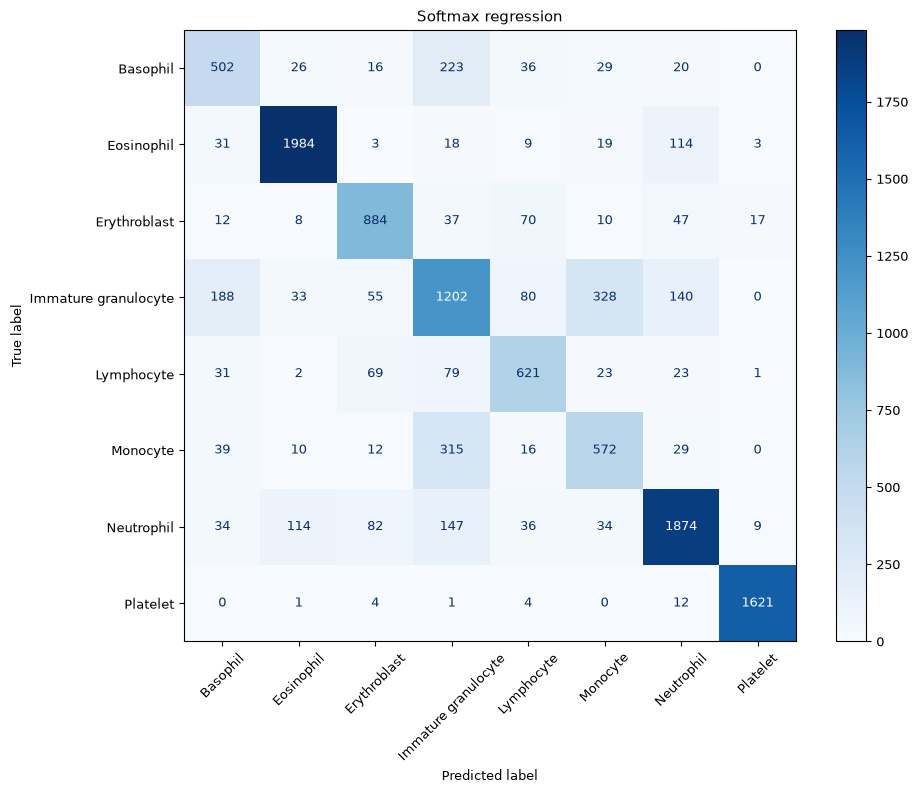

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_softmax_regression,
    display_labels=[
        "Basophil",
        "Eosinophil",
        "Erythroblast",
        "Immature granulocyte",
        "Lymphocyte",
        "Monocyte",
        "Neutrophil",
        "Platelet"
    ]
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Softmax regression")
plt.tight_layout()
plt.show()